In [2]:
import sys
import pandas as pd
sys.path.append("..")
from utils.market_data import get_candles

In [3]:
from datetime import date

ticker1 = "SBER"
ticker1_api_params = ["stock", "shares", "TQBR"]

ticker2 = "SRM6"
ticker2_api_params = ["futures", "forts", "RFUD"]

start_date = date(2026, 1, 2)
end_date = date(2026, 5, 23)

In [5]:
df1 = get_candles(ticker1, start_date, end_date, engine=ticker1_api_params[0], market=ticker1_api_params[1], board=ticker1_api_params[2], interval=10)
df2 = get_candles(ticker2, start_date, end_date, engine=ticker2_api_params[0], market=ticker2_api_params[1], board=ticker2_api_params[2], interval=10)

print(df1.head(1))
print(df2.head(1))

                      open  close   high    low       value  volume  \
timestamp                                                             
2026-01-05 06:50:00  300.0  300.0  300.0  300.0  21804600.0   72682   

                                     end  
timestamp                                 
2026-01-05 06:50:00  2026-01-05 06:59:59  
                      open  close   high    low  value  volume  \
timestamp                                                        
2026-01-05 09:00:00  32033  31901  32033  31899      0      71   

                                     end  
timestamp                                 
2026-01-05 09:00:00  2026-01-05 09:09:59  


In [6]:
df1.sort_values(by="timestamp", inplace=True)
df2.sort_values(by="timestamp", inplace=True)

df = pd.merge_asof(
    df1,
    df2,
    left_on="timestamp",
    right_on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("5m")
)
df.head(1)

,timestamp,open_x,close_x,high_x,low_x,value_x,volume_x,end_x,open_y,close_y,high_y,low_y,value_y,volume_y,end_y
0,2026-01-05 06:50:00,300.0,300.0,300.0,300.0,21804600.0,72682,2026-01-05 06:59:59,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
def rolling_ols(A, B, window):
    mean_A = A.rolling(window).mean()
    mean_B = B.rolling(window).mean()

    cov_AB = (A * B).rolling(window).mean() - mean_A * mean_B
    var_B  = (B * B).rolling(window).mean() - mean_B ** 2

    beta  = cov_AB / var_B
    alpha = mean_A - beta * mean_B

    return alpha, beta


alpha, beta = rolling_ols(df['close_x'], df['close_y'], window=20)
df['spread'] = df['close_x'] - beta * df['close_y'] - alpha

Text(0.5, 1.0, 'Spread of SBER and SRM6 \n Rolling OLS')

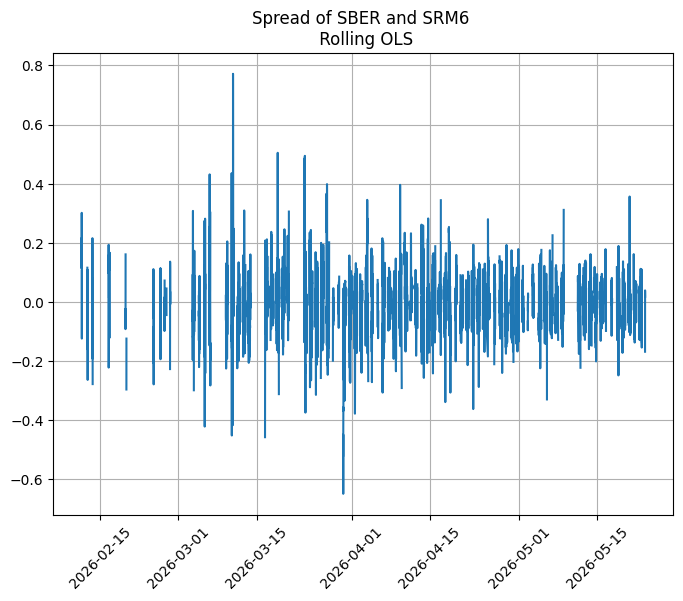

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
plt.plot(df['timestamp'], df['spread'])
plt.grid()
plt.xticks(rotation=45)
plt.title(f"Spread of {ticker1} and {ticker2} \n Rolling OLS")

In [21]:
backtest_df = df.copy().dropna()[['timestamp', 'close_x', 'close_y', 'spread']]
backtest_df.set_index('timestamp', inplace=True)
backtest_df

,close_x,close_y,spread
timestamp,,,
2026-02-11 15:40:00,305.15,32013.0,0.214811
2026-02-11 15:50:00,304.97,31991.0,0.113873
2026-02-11 16:00:00,305.37,32049.0,0.176526
2026-02-11 16:10:00,305.30,32031.0,0.132798
2026-02-11 16:20:00,305.53,32055.0,0.166286
...,...,...,...
2026-05-22 23:40:00,322.46,32624.0,-0.135757
2026-05-23 13:10:00,322.60,32624.0,-0.168089
2026-05-23 13:20:00,322.76,32614.0,0.039278


In [22]:
z_window = 20

mean = backtest_df['spread'].rolling(window=z_window).mean()
std = backtest_df['spread'].rolling(window=z_window).std()

backtest_df['z_score'] = (backtest_df['spread'] - mean)/std
backtest_df.dropna().head()

,close_x,close_y,spread,z_score
timestamp,,,,
2026-02-12 18:10:00,306.50,32102.0,0.107356,0.339654
2026-02-13 14:00:00,307.68,32230.0,0.070154,0.147785
2026-02-13 14:10:00,307.15,32201.0,-0.151674,-1.214614
2026-02-13 14:20:00,306.98,32171.0,-0.038774,-0.417893
2026-02-13 14:30:00,306.99,32142.0,0.215827,1.209398


In [40]:
z_entry = 1.5
z_exit = 0.5

backtest_df['signal'] = np.nan  
backtest_df.loc[backtest_df['z_score'] > z_entry, 'signal'] = 1
backtest_df.loc[backtest_df['z_score'] < -z_entry, 'signal'] = -1
backtest_df.loc[backtest_df['z_score'].abs() < z_exit, 'signal'] = 0

backtest_df.head()

,close_x,close_y,spread,z_score,signal,position
timestamp,,,,,,
2026-02-11 15:40:00,305.15,32013.0,0.214811,NaN,NaN,0.0
2026-02-11 15:50:00,304.97,31991.0,0.113873,NaN,NaN,0.0
2026-02-11 16:00:00,305.37,32049.0,0.176526,NaN,NaN,0.0
2026-02-11 16:10:00,305.30,32031.0,0.132798,NaN,NaN,0.0
2026-02-11 16:20:00,305.53,32055.0,0.166286,NaN,NaN,0.0


In [41]:
import numpy as np
backtest_df['position'] = backtest_df['signal'].ffill().fillna(0)